<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Part_finetuningRuBert_10_stage_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
# Конфигурация
MODEL_NAME = 'DeepPavlov/rubert-base-cased'
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 10


In [3]:
# Загрузка данных
train_df = pd.read_csv('in_domain_train.csv', usecols=['sentence', 'acceptable'])
test_df = pd.read_csv('in_domain_dev.csv', usecols=['sentence', 'acceptable'])

In [4]:
# Разделение на train/val
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['acceptable'],
    random_state=42
)

In [5]:
# Класс датасета
class ColaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [6]:
# Инициализация модели и токенизатора
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# Создание DataLoader
train_dataset = ColaDataset(train_df['sentence'].values, train_df['acceptable'].values, tokenizer)
val_dataset = ColaDataset(val_df['sentence'].values, val_df['acceptable'].values, tokenizer)
test_dataset = ColaDataset(test_df['sentence'].values, test_df['acceptable'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [8]:
# Обучение модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

best_val_loss = float('inf')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}')

    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # Валидация
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(

Epoch 10: 100%|██████████| 394/394 [04:31<00:00,  1.45it/s, loss=0.00236]


In [9]:
# Тестирование
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
all_preds = []
all_labels = []
all_probs = []

In [10]:
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

Confusion Matrix:
[[ 69 181]
 [ 20 713]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.28      0.41       250
           1       0.80      0.97      0.88       733

    accuracy                           0.80       983
   macro avg       0.79      0.62      0.64       983
weighted avg       0.79      0.80      0.76       983


ROC-AUC Score: 0.7101


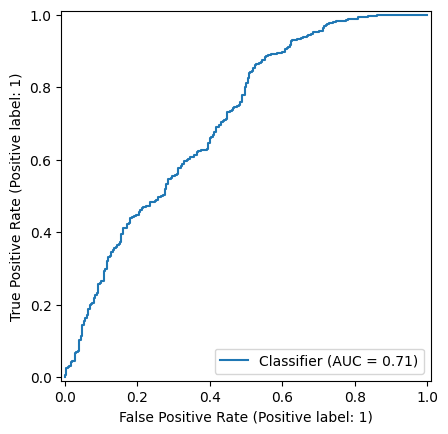

In [11]:
# Вывод метрик
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print(f"\nROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}")
RocCurveDisplay.from_predictions(all_labels, all_probs)